# 06. Topic Evolution

**Цель:** отследить эволюцию тем между двумя темпоральными срезами:
- **Срез A:** 2023-H1 (январь–июнь 2023)
- **Срез B:** 2024-H1 (январь–июнь 2024)

**Алгоритм:**
1. Нарезать данные на два среза из `posts_preprocessed.parquet`
2. Обучить BERTopic с `best_hparams.json` на каждом срезе независимо
3. Построить матрицу cosine similarity по `topic_embeddings_`
4. Посчитать Jaccard similarity по топ-10 словам
5. Агрегировать: `combined_score = 0.7 * cosine + 0.3 * jaccard`
6. LLM-as-a-Judge (Gemini) для пограничных пар (0.4 ≤ cosine ≤ 0.7)
7. Классифицировать изменения по таксономии Momeni et al. (ICWSM 2018):
   Emerged / Disappeared / Stable / Merged / Split
8. Визуализация + сохранение артефактов

**Источники:**
- Momeni et al. (ICWSM 2018) - таксономия topic evolution
- BERTopic `topic_embeddings_` - центроиды кластеров как dense topic vectors
- Tan & D'Souza (IRCDL 2025, arxiv:2502.07352) - D_rate промпт для LLM-судьи

In [3]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from bertopic import BERTopic
from dotenv import load_dotenv
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from hdbscan import HDBSCAN
import hdbscan.validity as dbcv_module
from openai import OpenAI
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
from umap import UMAP

warnings.filterwarnings("ignore")
load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

RANDOM_STATE = 42
COSINE_MATCH_THRESHOLD = 0.70  # порог для уверенного матча
COSINE_BORDER_LOW = 0.40  # нижняя граница пограничной зоны
COSINE_BORDER_HIGH = 0.70  # верхняя граница пограничной зоны -> идёт на LLM
JACCARD_WEIGHT = 0.30  # вес Jaccard в combined_score
COSINE_WEIGHT = 0.70  # вес cosine в combined_score
TOP_N_WORDS = 10  # сколько топ-слов брать для Jaccard

# Пути
DATA_PATH = Path("data/posts_preprocessed.parquet")
EMBEDDINGS_PATH = Path("data/embeddings_USER-bge-m3_300k.npy")
HPARAMS_PATH = Path("data/best_hparams.json")
MODELS_DIR = Path("models/topic_evolution")
RESULTS_DIR = Path("results/topic_evolution")
FIGURES_DIR = Path("figures")

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных и нарезка на срезы

In [5]:
df = pd.read_parquet(DATA_PATH)
embeddings_full = np.load(EMBEDDINGS_PATH)

assert len(df) == len(embeddings_full), "Размеры df и embeddings не совпадают!"

TOPICS_REDUCED_PATH = Path("data/topics_best_config_reduced.npy")
TOPICS_IDX_PATH = Path("data/topics_best_config_idx.npy")

if TOPICS_REDUCED_PATH.exists() and TOPICS_IDX_PATH.exists():
    topics_reduced = np.load(TOPICS_REDUCED_PATH)
    topics_idx = np.load(TOPICS_IDX_PATH)
    if len(topics_reduced) != len(topics_idx):
        raise ValueError(
            f"topics_reduced={len(topics_reduced)} does not match topics_idx={len(topics_idx)}"
        )
    keep_mask = topics_reduced != -1
    keep_idx = topics_idx[keep_mask]
    if len(keep_idx) == 0:
        raise ValueError("All documents were removed as noise.")
    if keep_idx.max() >= len(df):
        raise ValueError("topics_idx has values outside dataset range.")
    removed = int((~keep_mask).sum())
    df = df.iloc[keep_idx].reset_index(drop=True)
    embeddings_full = embeddings_full[keep_idx]
    print(f"Noise-filtered: removed {removed:,} docs, remaining {len(df):,}")
else:
    print("[!] Noise-filtering artifacts not found; using full dataset.")

df = df.reset_index(drop=True)
df["embed_idx"] = df.index

# post_date - datetime с timezone; нормализуем
df["post_date"] = pd.to_datetime(df["post_date"], utc=True)

print(f"Всего записей: {len(df):,}")
print(f"Период: {df['post_date'].min().date()} -> {df['post_date'].max().date()}")
print(f"Эмбеддинги: {embeddings_full.shape}")

[!] Noise-filtering artifacts not found; using full dataset.
Всего записей: 300,000
Период: 2022-01-01 -> 2025-06-24
Эмбеддинги: (300000, 1024)


In [6]:
# Нарезка на срезы
mask_A = (df["post_date"] >= "2023-01-01") & (df["post_date"] < "2023-07-01")
mask_B = (df["post_date"] >= "2024-01-01") & (df["post_date"] < "2024-07-01")

df_A = df[mask_A].copy().reset_index(drop=True)
df_B = df[mask_B].copy().reset_index(drop=True)

# Эмбеддинги срезов по оригинальным индексам
emb_A = embeddings_full[df[mask_A].index.values]
emb_B = embeddings_full[df[mask_B].index.values]

print(f"Срез A (2023-H1): {len(df_A):,} документов")
print(f"Срез B (2024-H1): {len(df_B):,} документов")
print(f"Эмбеддинги A: {emb_A.shape}")
print(f"Эмбеддинги B: {emb_B.shape}")

# Быстрая проверка месяцев
print("\nРаспределение A по месяцам:")
print(df_A["post_date"].dt.to_period("M").value_counts().sort_index())
print("\nРаспределение B по месяцам:")
print(df_B["post_date"].dt.to_period("M").value_counts().sort_index())

Срез A (2023-H1): 36,346 документов
Срез B (2024-H1): 50,096 документов
Эмбеддинги A: (36346, 1024)
Эмбеддинги B: (50096, 1024)

Распределение A по месяцам:
post_date
2023-01    5769
2023-02    5644
2023-03    6147
2023-04    5969
2023-05    6183
2023-06    6634
Freq: M, Name: count, dtype: int64

Распределение B по месяцам:
post_date
2024-01    7345
2024-02    7726
2024-03    9089
2024-04    8450
2024-05    8811
2024-06    8675
Freq: M, Name: count, dtype: int64


## 2. Обучение BERTopic на каждом срезе

Используем `best_hparams.json` из `05_hyperparams.ipynb`.
Оба среза обучаем с одинаковыми параметрами для корректного сравнения.

In [ ]:
with open(HPARAMS_PATH, "r", encoding="utf-8") as f:
    best_hparams = json.load(f)

print("Загружены best_hparams:")
for k, v in best_hparams.items():
    print(f"  {k}: {v}")


ARTIFACT_STOP_WORDS = [
    "truekpru",
    "truekpspbru",
    "подписаться",
    "наш",
    "известный",
    "масштабный",
    "важный",
    "подписаться truekpru",
]


def build_bertopic(hparams: dict, n_docs: int = 300_000) -> BERTopic:
    """Создаёт BERTopic с гиперпараметрами, масштабированными под размер среза."""
    scale = n_docs / 300_000
    min_samples_scaled = max(5, int(hparams["min_samples"] * scale))
    min_cluster_size_scaled = max(10, int(hparams["min_cluster_size"] * scale))

    print(
        f"  Масштаб: {scale:.2f} | min_samples: {hparams['min_samples']} -> {min_samples_scaled} | min_cluster_size: {hparams['min_cluster_size']} -> {min_cluster_size_scaled}"
    )

    umap_model = UMAP(
        n_neighbors=hparams["n_neighbors"],
        n_components=hparams["n_components"],
        min_dist=0.0,
        metric="cosine",
        random_state=RANDOM_STATE,
        low_memory=False,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size_scaled,
        min_samples=min_samples_scaled,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    vectorizer_model = CountVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.85,
        max_features=30_000,
        stop_words=ARTIFACT_STOP_WORDS,
    )
    return BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        language="multilingual",
        top_n_words=TOP_N_WORDS,
        verbose=True,
    )

Загружены best_hparams:
  n_neighbors: 51
  n_components: 15
  min_cluster_size: 120
  min_samples: 142


In [8]:
# --- Срез A ---
print("=" * 55)
print("Обучение модели A (2023-H1)...")
print("=" * 55)

model_A = build_bertopic(best_hparams, n_docs=len(df_A))
docs_A = df_A["text_lemm"].tolist()
topics_A, _ = model_A.fit_transform(docs_A, embeddings=emb_A)
df_A["topic"] = topics_A

n_topics_A = model_A.get_topic_info().shape[0] - 1
noise_A = (np.array(topics_A) == -1).mean()
print(f"\nМодель A: {n_topics_A} тем | Noise Ratio: {noise_A:.3f}")

model_A.save(str(MODELS_DIR / "bertopic_2023H1"))
print(f"Сохранено: {MODELS_DIR}/bertopic_2023H1")

2026-05-07 14:43:01,319 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Обучение модели A (2023-H1)...
  Масштаб: 0.12 | min_samples: 142 -> 17 | min_cluster_size: 120 -> 14


2026-05-07 14:44:27,499 - BERTopic - Dimensionality - Completed ✓
2026-05-07 14:44:27,502 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 14:44:32,549 - BERTopic - Cluster - Completed ✓
2026-05-07 14:44:32,558 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 14:44:37,657 - BERTopic - Representation - Completed ✓
2026-05-07 14:44:39,000 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.



Модель A: 225 тем | Noise Ratio: 0.503
Сохранено: models\topic_evolution/bertopic_2023H1


In [9]:
# --- Срез B ---
print("=" * 55)
print("Обучение модели B (2024-H1)...")
print("=" * 55)

model_B = build_bertopic(best_hparams, n_docs=len(df_B))
docs_B = df_B["text_lemm"].tolist()
topics_B, _ = model_B.fit_transform(docs_B, embeddings=emb_B)
df_B["topic"] = topics_B

n_topics_B = model_B.get_topic_info().shape[0] - 1
noise_B = (np.array(topics_B) == -1).mean()
print(f"\nМодель B: {n_topics_B} тем | Noise Ratio: {noise_B:.3f}")

model_B.save(str(MODELS_DIR / "bertopic_2024H1"))
print(f"Сохранено: {MODELS_DIR}/bertopic_2024H1")

2026-05-07 14:44:53,680 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Обучение модели B (2024-H1)...
  Масштаб: 0.17 | min_samples: 142 -> 23 | min_cluster_size: 120 -> 20


2026-05-07 14:46:28,246 - BERTopic - Dimensionality - Completed ✓
2026-05-07 14:46:28,250 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 14:46:31,068 - BERTopic - Cluster - Completed ✓
2026-05-07 14:46:31,075 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 14:46:38,442 - BERTopic - Representation - Completed ✓
2026-05-07 14:46:40,489 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.



Модель B: 243 тем | Noise Ratio: 0.457
Сохранено: models\topic_evolution/bertopic_2024H1


## 3. Cosine Similarity Matrix

`topic_embeddings_` в BERTopic - центроиды документных эмбеддингов кластера.
Строим матрицу попарных cosine similarity между всеми темами A и B.
Тема -1 (шум) исключается.

In [10]:
# Извлекаем topic_embeddings_ без шума (-1)
# get_topics() возвращает dict {topic_id: [(word, score), ...]}
topic_ids_A = sorted([t for t in model_A.get_topics().keys() if t != -1])
topic_ids_B = sorted([t for t in model_B.get_topics().keys() if t != -1])

print(f"Тем в срезе A: {len(topic_ids_A)}")
print(f"Тем в срезе B: {len(topic_ids_B)}")

# topic_embeddings_ - shape (n_topics + 1, dim), индекс 0 = тема -1 (outliers)
# BERTopic хранит эмбеддинги начиная с индекса 0 = тема -1, 1 = тема 0, ...
# Поэтому для темы t берём topic_embeddings_[t + 1]
emb_topics_A = np.array([model_A.topic_embeddings_[t + 1] for t in topic_ids_A])
emb_topics_B = np.array([model_B.topic_embeddings_[t + 1] for t in topic_ids_B])

print(f"\nФорма матрицы эмбеддингов тем A: {emb_topics_A.shape}")
print(f"Форма матрицы эмбеддингов тем B: {emb_topics_B.shape}")

# Матрица cosine similarity: shape (n_topics_A, n_topics_B)
sim_matrix = cosine_similarity(emb_topics_A, emb_topics_B)
print(f"\nМатрица similarity: {sim_matrix.shape}")
print(
    f"Min: {sim_matrix.min():.4f} | Max: {sim_matrix.max():.4f} | Mean: {sim_matrix.mean():.4f}"
)

Тем в срезе A: 225
Тем в срезе B: 243

Форма матрицы эмбеддингов тем A: (225, 1024)
Форма матрицы эмбеддингов тем B: (243, 1024)

Матрица similarity: (225, 243)
Min: 0.2565 | Max: 0.9963 | Mean: 0.5307


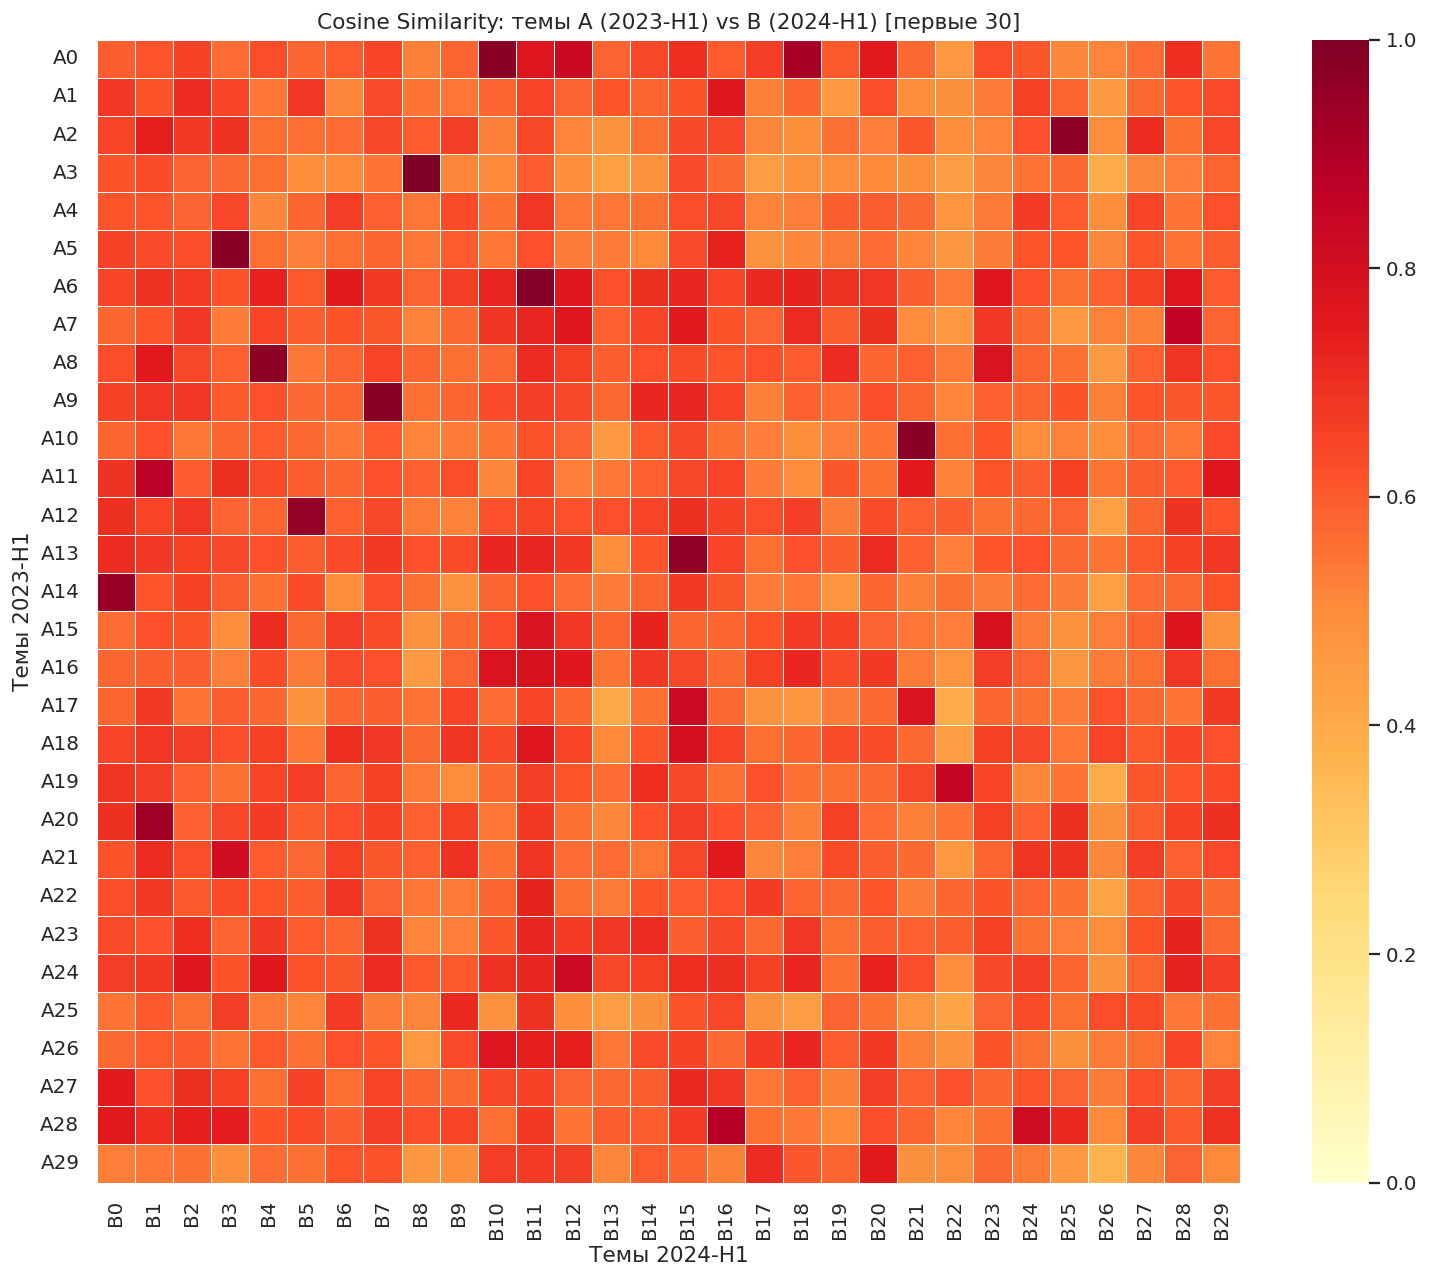

In [11]:
# Визуализация матрицы similarity (первые 30 тем)
SHOW_N = min(30, len(topic_ids_A), len(topic_ids_B))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    sim_matrix[:SHOW_N, :SHOW_N],
    ax=ax,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    xticklabels=[f"B{t}" for t in topic_ids_B[:SHOW_N]],
    yticklabels=[f"A{t}" for t in topic_ids_A[:SHOW_N]],
    linewidths=0.3,
    annot=(SHOW_N <= 20),  # аннотации только если матрица небольшая
    fmt=".2f" if SHOW_N <= 20 else "",
)
ax.set_title(f"Cosine Similarity: темы A (2023-H1) vs B (2024-H1) [первые {SHOW_N}]")
ax.set_xlabel("Темы 2024-H1")
ax.set_ylabel("Темы 2023-H1")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "07_[topic_evolution]_similarity_matrix.png", bbox_inches="tight"
)
plt.show()

## 4. Jaccard Similarity по топ-словам

In [12]:
def get_top_words(model: BERTopic, topic_id: int, n: int = TOP_N_WORDS) -> set[str]:
    """Возвращает множество топ-N слов темы."""
    return {word for word, _ in model.get_topic(topic_id)[:n]}


def jaccard_similarity(set_a: set, set_b: set) -> float:
    """J(A,B) = |A∩B| / |A∪B|."""
    union = set_a | set_b
    if not union:
        return 0.0
    return len(set_a & set_b) / len(union)


# Заранее строим словари топ-слов
words_A = {t: get_top_words(model_A, t) for t in topic_ids_A}
words_B = {t: get_top_words(model_B, t) for t in topic_ids_B}

# Матрица Jaccard: shape (n_topics_A, n_topics_B)
jaccard_matrix = np.array(
    [
        [jaccard_similarity(words_A[a], words_B[b]) for b in topic_ids_B]
        for a in topic_ids_A
    ]
)

print(f"Матрица Jaccard: {jaccard_matrix.shape}")
print(
    f"Min: {jaccard_matrix.min():.4f} | Max: {jaccard_matrix.max():.4f} | Mean: {jaccard_matrix.mean():.4f}"
)

# Пример: топ-5 пар с наибольшим Jaccard
print("\nТоп-5 пар по Jaccard:")
flat_idx = np.argsort(jaccard_matrix.ravel())[::-1][:5]
for idx in flat_idx:
    i, j = divmod(idx, len(topic_ids_B))
    ta, tb = topic_ids_A[i], topic_ids_B[j]
    print(f"  A{ta} vs B{tb}: Jaccard={jaccard_matrix[i, j]:.3f}")
    print(f"    A: {sorted(words_A[ta])[:5]}")
    print(f"    B: {sorted(words_B[tb])[:5]}")

Матрица Jaccard: (225, 243)
Min: 0.0000 | Max: 0.8182 | Mean: 0.0025

Топ-5 пар по Jaccard:
  A1 vs B56: Jaccard=0.818
    A: ['ветер', 'воздух', 'градус', 'дождь', 'ожидаться']
    B: ['ветер', 'воздух', 'градус', 'дождь', 'ожидаться']
  A52 vs B87: Jaccard=0.667
    A: ['валюта', 'валютный', 'доллар', 'евро', 'курс']
    B: ['валюта', 'доллар', 'доллар евро', 'евро', 'курс']
  A104 vs B104: Jaccard=0.667
    A: ['альянс', 'генсек', 'генсек нато', 'йенс', 'йенс столтенберг']
    B: ['альянс', 'генсек', 'генсек нато', 'йенс', 'йенс столтенберг']
  A10 vs B21: Jaccard=0.667
    A: ['актёр', 'возраст', 'возраст год', 'год жизнь', 'жизнь']
    B: ['актёр', 'возраст год', 'год жизнь', 'жизнь', 'прощание']
  A116 vs B148: Jaccard=0.667
    A: ['вещество', 'грамм', 'задержать', 'запретить вещество', 'изъять']
    B: ['вещество', 'грамм', 'задержать', 'запретить вещество', 'изъять']


## 5. Combined Score и предварительный маппинг

`combined_score = 0.7 * cosine + 0.3 * jaccard`

Порог 0.7 по cosine - эмпирически обоснованный стандарт (ablation на 0.5–0.95).
Jaccard добавляет интерпретируемость: два кластера могут быть близки семантически,
но иметь разные ключевые слова из-за концептуального дрейфа.

In [13]:
combined_matrix = COSINE_WEIGHT * sim_matrix + JACCARD_WEIGHT * jaccard_matrix

# Для каждой темы A находим лучший матч в B
best_match_A2B = {}  # topic_id_A -> {topic_id_B, cosine, jaccard, combined}
for i, ta in enumerate(topic_ids_A):
    j_best = int(np.argmax(combined_matrix[i]))
    tb_best = topic_ids_B[j_best]
    best_match_A2B[ta] = {
        "matched_B": tb_best,
        "cosine": float(sim_matrix[i, j_best]),
        "jaccard": float(jaccard_matrix[i, j_best]),
        "combined": float(combined_matrix[i, j_best]),
    }

# Для каждой темы B находим лучший матч в A (нужно для Merged/Split)
best_match_B2A = {}
for j, tb in enumerate(topic_ids_B):
    i_best = int(np.argmax(combined_matrix[:, j]))
    ta_best = topic_ids_A[i_best]
    best_match_B2A[tb] = {
        "matched_A": ta_best,
        "cosine": float(sim_matrix[i_best, j]),
        "jaccard": float(jaccard_matrix[i_best, j]),
        "combined": float(combined_matrix[i_best, j]),
    }

# Статистика распределения combined scores
all_best_cosines = [v["cosine"] for v in best_match_A2B.values()]
print("Распределение max cosine (A->B):")
for threshold in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    count = sum(1 for c in all_best_cosines if c >= threshold)
    print(
        f"  cosine ≥ {threshold}: {count}/{len(all_best_cosines)} тем ({count / len(all_best_cosines) * 100:.1f}%)"
    )

Распределение max cosine (A->B):
  cosine ≥ 0.4: 225/225 тем (100.0%)
  cosine ≥ 0.5: 225/225 тем (100.0%)
  cosine ≥ 0.6: 223/225 тем (99.1%)
  cosine ≥ 0.7: 214/225 тем (95.1%)
  cosine ≥ 0.8: 173/225 тем (76.9%)
  cosine ≥ 0.9: 109/225 тем (48.4%)


## 6. LLM-as-a-Judge

Для пограничных пар (0.4 ≤ cosine < 0.7) запрашиваем LLM.
Используем адаптированный D_rate промпт (Tan & D'Souza, IRCDL 2025).

Модель: `google/gemini-2.5-flash-lite-preview-09-2025` через routerai.ru (OpenAI-like API).

In [14]:
LLM_API_KEY = os.getenv("LLM_API_KEY")
LLM_API_BASE_URL = "https://routerai.ru/api/v1"
LLM_MODEL = "google/gemini-2.5-flash-lite-preview-09-2025"

llm_client = OpenAI(
    api_key=LLM_API_KEY,
    base_url=LLM_API_BASE_URL,
)

# Быстрый тест подключения
try:
    test_resp = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": "Ответь одним словом: работает?"}],
        max_tokens=10,
    )
    print(f"LLM API OK: {test_resp.choices[0].message.content.strip()}")
except Exception as e:
    print(f"LLM API ERROR: {e}")

LLM API ERROR: Error code: 401 - {'error': '401 Unauthorized'}


In [15]:
SYSTEM_PROMPT = """Ты эксперт по тематическому моделированию текстов.
Тебе будут даны два набора ключевых слов, представляющих две темы из новостных Telegram-каналов.
Твоя задача - определить, описывают ли они одну и ту же тему или разные темы.
Отвечай строго в формате JSON, без пояснений и markdown."""


def llm_judge_pair(
    words_a: set,
    words_b: set,
    topic_id_a: int,
    topic_id_b: int,
) -> dict:
    """
    LLM-as-a-Judge для пары тем.

    Возвращает:
        {
            "same_topic": bool,
            "confidence": "high" | "medium" | "low",
            "reasoning": str
        }

    Адаптировано из D_rate промпта (Tan & D'Souza, IRCDL 2025, arxiv:2502.07352).
    Оригинальная шкала: 1 (partial overlap) -> 3 (highly distinctive).
    Инвертируем: 3 = та же тема, 1 = разные темы.
    """
    words_a_str = ", ".join(sorted(words_a)[:10])
    words_b_str = ", ".join(sorted(words_b)[:10])

    user_prompt = f"""Проанализируй две темы из русскоязычных новостных Telegram-каналов.

Тема A (срез 2023-H1, topic_id={topic_id_a}):
Ключевые слова: [{words_a_str}]

Тема B (срез 2024-H1, topic_id={topic_id_b}):
Ключевые слова: [{words_b_str}]

Определи:
1. Описывают ли эти две темы одну и ту же тематику? (true/false)
2. Уверенность в ответе: high (очевидно), medium (вероятно), low (неясно)
3. Краткое обоснование на русском языке (1-2 предложения)

Ответь строго в формате JSON:
{{"same_topic": true/false, "confidence": "high"/"medium"/"low", "reasoning": "..."}}"""

    try:
        response = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt},
            ],
            max_tokens=200,
            temperature=0.1,  # низкая температура для стабильности
            response_format={"type": "json_object"},
        )
        content = response.choices[0].message.content.strip()
        result = json.loads(content)
        # Валидация структуры
        assert "same_topic" in result and "confidence" in result
        return result
    except Exception as e:
        # При ошибке возвращаем нейтральный результат
        return {"same_topic": False, "confidence": "low", "reasoning": f"ERROR: {e}"}


print("Функции LLM-судьи определены")

Функции LLM-судьи определены


In [16]:
# Определяем пограничные пары для LLM
border_pairs = [
    (ta, best_match_A2B[ta]["matched_B"], best_match_A2B[ta]["cosine"])
    for ta in topic_ids_A
    if COSINE_BORDER_LOW <= best_match_A2B[ta]["cosine"] < COSINE_BORDER_HIGH
]

print(f"Пар для LLM-судьи: {len(border_pairs)}")
print(f"(cosine в [{COSINE_BORDER_LOW}, {COSINE_BORDER_HIGH}))")

# Запускаем LLM для пограничных пар
llm_results = {}  # (ta, tb) -> dict

for ta, tb, cosine_score in tqdm(border_pairs, desc="LLM-as-a-Judge"):
    result = llm_judge_pair(
        words_A[ta],
        words_B[tb],
        topic_id_a=ta,
        topic_id_b=tb,
    )
    llm_results[(ta, tb)] = result

# Статистика LLM-решений
if llm_results:
    same_count = sum(1 for r in llm_results.values() if r["same_topic"])
    diff_count = len(llm_results) - same_count
    high_conf = sum(1 for r in llm_results.values() if r["confidence"] == "high")
    medium_conf = sum(1 for r in llm_results.values() if r["confidence"] == "medium")
    low_conf = sum(1 for r in llm_results.values() if r["confidence"] == "low")
    print(f"LLM результаты:")
    print(f"  Та же тема: {same_count} | Разные: {diff_count}")
    print(f"  Confidence: high={high_conf}, medium={medium_conf}, low={low_conf}")

    # Несколько примеров
    print("\nПримеры LLM-решений:")
    for (ta, tb), result in list(llm_results.items())[:3]:
        cosine_val = best_match_A2B[ta]["cosine"]
        print(
            f"  A{ta} vs B{tb} | cosine={cosine_val:.3f} | same={result['same_topic']} | conf={result['confidence']}"
        )
        print(f"    A: {sorted(words_A[ta])[:5]}")
        print(f"    B: {sorted(words_B[tb])[:5]}")
        print(f"    Reasoning: {result.get('reasoning', '')}")

Пар для LLM-судьи: 11
(cosine в [0.4, 0.7))


LLM-as-a-Judge:   0%|          | 0/11 [00:00<?, ?it/s]

LLM результаты:
  Та же тема: 0 | Разные: 11
  Confidence: high=0, medium=0, low=11

Примеры LLM-решений:
  A98 vs B1 | cosine=0.694 | same=False | conf=low
    A: ['автомобиль', 'взрыв', 'захар', 'захар прилепин', 'нижегородский']
    B: ['задержать', 'избить', 'мужчина', 'нож', 'подозревать']
    Reasoning: ERROR: Error code: 401 - {'error': '401 Unauthorized'}
  A146 vs B158 | cosine=0.699 | same=False | conf=low
    A: ['башкирия', 'инвестиционный', 'млн', 'млн рубль', 'млрд']
    B: ['василий голубеть', 'голубеть', 'завод', 'млрд', 'млрд рубль']
    Reasoning: ERROR: Error code: 401 - {'error': '401 Unauthorized'}
  A147 vs B163 | cosine=0.688 | same=False | conf=low
    A: ['аппарат', 'атлантика', 'береговой', 'затонуть', 'обломок']
    B: ['афганистан', 'борт', 'выжить', 'гора', 'крушение']
    Reasoning: ERROR: Error code: 401 - {'error': '401 Unauthorized'}


In [17]:
import pandas as pd

weight_configs = {
    "Cosine 1.0 / Jaccard 0.0": (1.0, 0.0),
    "Cosine 0.7 / Jaccard 0.3": (0.7, 0.3),
    "Cosine 0.5 / Jaccard 0.5": (0.5, 0.5),
    "Cosine 0.3 / Jaccard 0.7": (0.3, 0.7),
    "Cosine 0.0 / Jaccard 1.0": (0.0, 1.0),
}

rows = []
for ta, tb, cosine_val in border_pairs:
    i = topic_ids_A.index(ta)
    j = topic_ids_B.index(tb)
    jac = float(jaccard_matrix[i, j])
    llm_verdict = llm_results.get((ta, tb), {}).get("same_topic", None)

    row = {
        "pair": f"A{ta}->B{tb}",
        "cosine": round(cosine_val, 4),
        "jaccard": round(jac, 4),
        "llm_same": llm_verdict,
    }
    for name, (w_cos, w_jac) in weight_configs.items():
        row[name] = round(w_cos * cosine_val + w_jac * jac, 4)
    rows.append(row)

ablation_df = pd.DataFrame(rows).sort_values("cosine", ascending=False)
print(ablation_df.to_string(index=False))

# Check: pair with llm_same=True should rank highest by combined_score
for name in weight_configs:
    same_scores = ablation_df[ablation_df["llm_same"] == True][name].values
    diff_scores = ablation_df[ablation_df["llm_same"] == False][name].values
    if len(same_scores):
        rank = (diff_scores > same_scores[0]).sum() + 1
        print(
            f"{name}: 'same topic' pair ranks {rank} of {len(ablation_df)} by combined_score"
        )

      pair  cosine  jaccard  llm_same  Cosine 1.0 / Jaccard 0.0  Cosine 0.7 / Jaccard 0.3  Cosine 0.5 / Jaccard 0.5  Cosine 0.3 / Jaccard 0.7  Cosine 0.0 / Jaccard 1.0
A146->B158  0.6993   0.1765     False                    0.6993                    0.5424                    0.4379                    0.3333                    0.1765
   A98->B1  0.6936   0.0000     False                    0.6936                    0.4855                    0.3468                    0.2081                    0.0000
A147->B163  0.6881   0.0000     False                    0.6881                    0.4816                    0.3440                    0.2064                    0.0000
A212->B152  0.6855   0.0526     False                    0.6855                    0.4956                    0.3691                    0.2425                    0.0526
  A195->B0  0.6535   0.0000     False                    0.6535                    0.4574                    0.3267                    0.1960                   

## 7. Классификация изменений тем

Таксономия Momeni et al. (ICWSM 2018):
- **Emerged** - нет матча в A с cosine ≥ threshold
- **Disappeared** - нет матча в B с cosine ≥ threshold
- **Stable** - 1:1 матч выше threshold
- **Merged** - несколько тем A -> одна тема B (many-to-one)
- **Split** - одна тема A -> несколько тем B (one-to-many)

LLM-результат используется для уточнения пограничных пар:
если cosine в [0.4, 0.7) и LLM говорит `same_topic=true` -> считаем матчем.

In [18]:
def is_match(ta: int, tb: int, cosine_val: float) -> bool:
    """
    Определяет, являются ли темы A и B матчем.
    - cosine ≥ COSINE_MATCH_THRESHOLD -> уверенный матч
    - cosine в [BORDER_LOW, BORDER_HIGH) -> спрашиваем LLM
    - cosine < BORDER_LOW -> не матч
    """
    if cosine_val >= COSINE_MATCH_THRESHOLD:
        return True
    if COSINE_BORDER_LOW <= cosine_val < COSINE_BORDER_HIGH:
        llm_result = llm_results.get((ta, tb))
        if llm_result is not None:
            return llm_result["same_topic"]
    return False


# --- Строим финальный маппинг ---

# matched_A2B[ta] = tb если матч найден
matched_A2B: dict[int, int] = {}
for ta in topic_ids_A:
    tb_best = best_match_A2B[ta]["matched_B"]
    cosine_val = best_match_A2B[ta]["cosine"]
    if is_match(ta, tb_best, cosine_val):
        matched_A2B[ta] = tb_best

matched_B2A: dict[int, int] = {}
for tb in topic_ids_B:
    ta_best = best_match_B2A[tb]["matched_A"]
    cosine_val = best_match_B2A[tb]["cosine"]
    if is_match(ta_best, tb, cosine_val):
        matched_B2A[tb] = ta_best

print(f"Тем A с матчем в B: {len(matched_A2B)}/{len(topic_ids_A)}")
print(f"Тем B с матчем в A: {len(matched_B2A)}/{len(topic_ids_B)}")

Тем A с матчем в B: 214/225
Тем B с матчем в A: 234/243


In [19]:
from collections import defaultdict

evolution_records = []

# --- Emerged: темы в B без матча в A ---
for tb in topic_ids_B:
    if tb not in matched_B2A:
        evolution_records.append(
            {
                "type": "Emerged",
                "topic_B": tb,
                "topic_A": None,
                "cosine": None,
                "jaccard": None,
                "words_B": sorted(words_B[tb])[:5],
                "words_A": None,
            }
        )

# --- Disappeared: темы в A без матча в B ---
for ta in topic_ids_A:
    if ta not in matched_A2B:
        evolution_records.append(
            {
                "type": "Disappeared",
                "topic_A": ta,
                "topic_B": None,
                "cosine": None,
                "jaccard": None,
                "words_A": sorted(words_A[ta])[:5],
                "words_B": None,
            }
        )

# --- Для Stable / Merged / Split анализируем маппинг ---
# Считаем: сколько тем A смотрят на одну тему B (Merged)
b_sources: dict[int, list[int]] = defaultdict(list)  # tb -> [ta, ta, ...]
for ta, tb in matched_A2B.items():
    b_sources[tb].append(ta)

# Считаем: сколько тем B получает одна тема A (Split)
a_targets: dict[int, list[int]] = defaultdict(list)  # ta -> [tb, tb, ...]
for ta, tb in matched_A2B.items():
    a_targets[ta].append(tb)

for ta in topic_ids_A:
    if ta not in matched_A2B:
        continue

    tb = matched_A2B[ta]
    cosine_val = best_match_A2B[ta]["cosine"]
    jaccard_val = best_match_A2B[ta]["jaccard"]

    # Merged: несколько A -> один B
    if len(b_sources[tb]) > 1 and b_sources[tb][0] == ta:
        # Записываем только для первой темы A в группе, чтобы не дублировать
        evolution_records.append(
            {
                "type": "Merged",
                "topic_A": b_sources[tb],  # список всех A
                "topic_B": tb,
                "cosine": cosine_val,
                "jaccard": jaccard_val,
                "words_A": sorted(words_A[ta])[:5],
                "words_B": sorted(words_B[tb])[:5],
            }
        )
        continue

    # Stable: 1:1 матч
    if len(b_sources[tb]) == 1:
        evolution_records.append(
            {
                "type": "Stable",
                "topic_A": ta,
                "topic_B": tb,
                "cosine": cosine_val,
                "jaccard": jaccard_val,
                "words_A": sorted(words_A[ta])[:5],
                "words_B": sorted(words_B[tb])[:5],
            }
        )

# Split обрабатывается отдельно через a_targets
# (нужно проверить темы B, у которых несколько источников A через обратный маппинг)
# Здесь используем упрощение через b_sources: Split = тема A, чей tb уже занят другим ta
# Полная реализация через one-to-many анализ обратного маппинга:
processed_as_merged = {ta for ta, tb in matched_A2B.items() if len(b_sources[tb]) > 1}
# Split: тема A -> несколько тем B (по обратному маппингу это случай,
# когда несколько B указывают на одну A как best_match)
a_claims: dict[int, list[int]] = defaultdict(list)  # ta -> все tb где best_match = ta
for tb in topic_ids_B:
    ta_best = best_match_B2A[tb]["matched_A"]
    if is_match(ta_best, tb, best_match_B2A[tb]["cosine"]):
        a_claims[ta_best].append(tb)

for ta, tb_list in a_claims.items():
    if len(tb_list) > 1 and ta not in processed_as_merged:
        evolution_records.append(
            {
                "type": "Split",
                "topic_A": ta,
                "topic_B": tb_list,  # список всех B
                "cosine": best_match_A2B.get(ta, {}).get("cosine"),
                "jaccard": best_match_A2B.get(ta, {}).get("jaccard"),
                "words_A": sorted(words_A[ta])[:5],
                "words_B": sorted(words_B[tb_list[0]])[:5],
            }
        )

# Итоговая статистика
evo_df = pd.DataFrame(evolution_records)
print("=== Таксономия Topic Evolution ===")
print(evo_df["type"].value_counts().to_string())
print(f"\nИтого записей: {len(evo_df)}")

=== Таксономия Topic Evolution ===
type
Stable         98
Merged         47
Split          28
Disappeared    11
Emerged         9

Итого записей: 193


## 8. Визуализация результатов

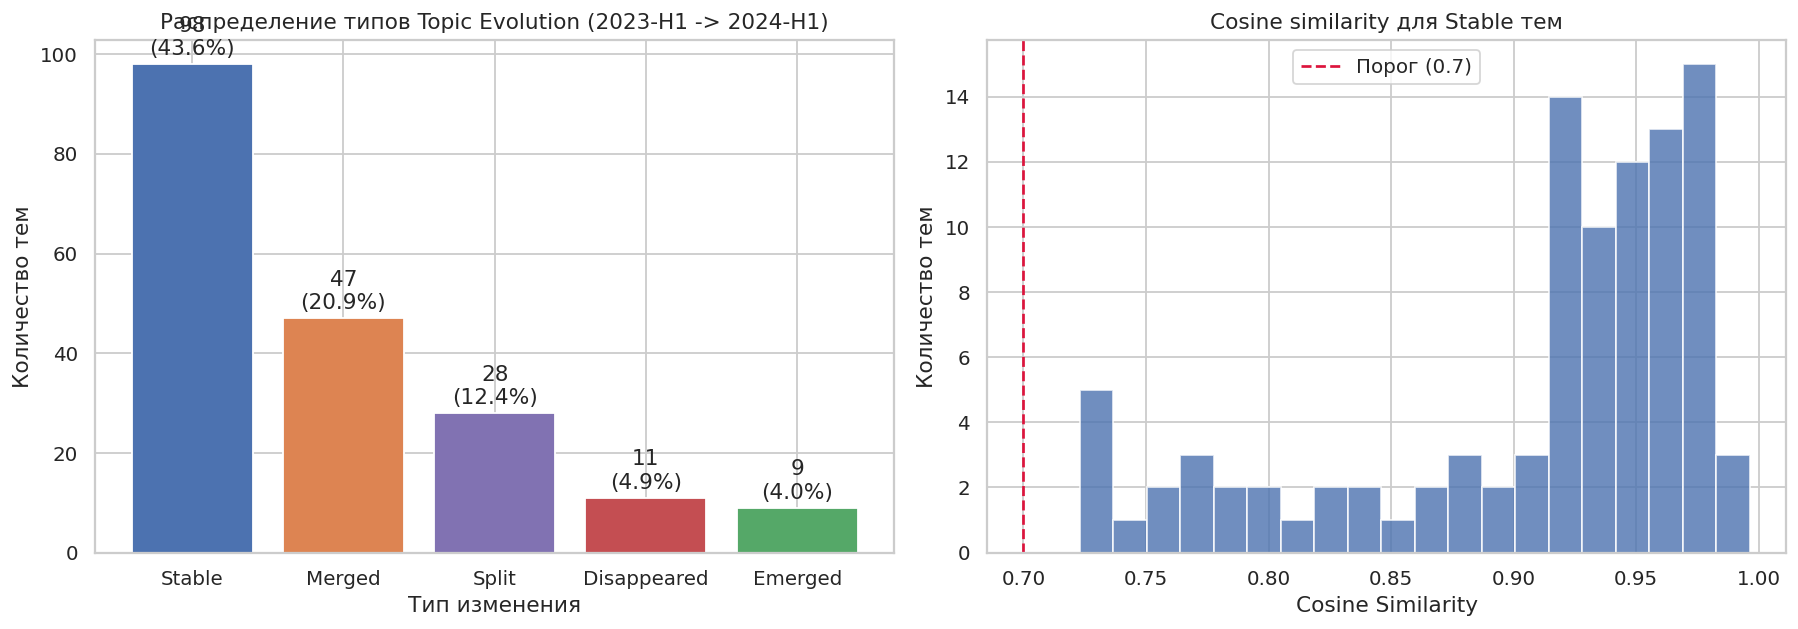

In [20]:
# --- Диаграмма распределения типов ---
type_counts = evo_df["type"].value_counts()
colors_map = {
    "Stable": "#4C72B0",
    "Emerged": "#55A868",
    "Disappeared": "#C44E52",
    "Merged": "#DD8452",
    "Split": "#8172B2",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bar_colors = [colors_map.get(t, "grey") for t in type_counts.index]
bars = axes[0].bar(
    type_counts.index, type_counts.values, color=bar_colors, edgecolor="white"
)
axes[0].bar_label(
    bars,
    labels=[f"{v}\n({v / len(topic_ids_A) * 100:.1f}%)" for v in type_counts.values],
    padding=3,
)
axes[0].set_title("Распределение типов Topic Evolution (2023-H1 -> 2024-H1)")
axes[0].set_ylabel("Количество тем")
axes[0].set_xlabel("Тип изменения")

# Распределение cosine similarity для Stable тем
stable_cosines = [
    r["cosine"]
    for r in evolution_records
    if r["type"] == "Stable" and r["cosine"] is not None
]
if stable_cosines:
    axes[1].hist(stable_cosines, bins=20, color="#4C72B0", edgecolor="white", alpha=0.8)
    axes[1].axvline(
        COSINE_MATCH_THRESHOLD,
        color="crimson",
        linestyle="--",
        linewidth=1.5,
        label=f"Порог ({COSINE_MATCH_THRESHOLD})",
    )
    axes[1].set_title("Cosine similarity для Stable тем")
    axes[1].set_xlabel("Cosine Similarity")
    axes[1].set_ylabel("Количество тем")
    axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_[topic_evolution]_taxonomy.png", bbox_inches="tight")
plt.show()

In [21]:
# --- Примеры Emerged тем (новые в 2024) ---
print("=== Примеры Emerged тем (2024-H1) ===")
emerged = evo_df[evo_df["type"] == "Emerged"].head(10)
for _, row in emerged.iterrows():
    tb = row["topic_B"]
    count_b = (np.array(topics_B) == tb).sum()
    print(f"  Тема B{tb} ({count_b} docs): {sorted(words_B[tb])[:7]}")

print("\n=== Примеры Disappeared тем (исчезли к 2024) ===")
disappeared = evo_df[evo_df["type"] == "Disappeared"].head(10)
for _, row in disappeared.iterrows():
    ta = row["topic_A"]
    count_a = (np.array(topics_A) == ta).sum()
    print(f"  Тема A{ta} ({count_a} docs): {sorted(words_A[ta])[:7]}")

print("\n=== Примеры Stable тем (топ-5 по cosine) ===")
stable = evo_df[evo_df["type"] == "Stable"].copy()
if not stable.empty:
    stable = stable.sort_values("cosine", ascending=False).head(5)
    for _, row in stable.iterrows():
        print(
            f"  A{row['topic_A']} -> B{row['topic_B']} | cosine={row['cosine']:.3f} | jaccard={row['jaccard']:.3f}"
        )
        print(f"    A: {row['words_A']}")
        print(f"    B: {row['words_B']}")

=== Примеры Emerged тем (2024-H1) ===
  Тема B102 (85 docs): ['весна', 'вещь', 'гардероб', 'мода', 'модный', 'назвать', 'одежда']
  Тема B183 (35 docs): ['вертолёт', 'военный вертолёт', 'гур украина', 'испания', 'испанский', 'кузьмин', 'лётчик']
  Тема B185 (34 docs): ['выразить', 'выразить соболезнование', 'крокус', 'крокус сити', 'осуждать', 'сити холл', 'соболезнование']
  Тема B190 (34 docs): ['бюллетень', 'воспрепятствование', 'зелёнка', 'избирательный', 'избирательный комиссия', 'избирательный право', 'избирательный участок']
  Тема B194 (33 docs): ['андрей', 'губернатор', 'губернатор мурманский', 'мурманский', 'мурманский область', 'нападение', 'напасть']
  Тема B208 (30 docs): ['актёр', 'актёр никита', 'арест', 'дебош', 'кологривый', 'никита', 'никита кологривый']
  Тема B223 (27 docs): ['бортник', 'группа', 'депортация', 'егор', 'израиль', 'иноагент', 'музыкант']
  Тема B235 (23 docs): ['домохозяйка', 'загрязнение', 'очистить', 'посоветовать', 'пятно', 'способ', 'средство']
  

## 9. Метрики качества Topic Evolution

Считаем стандартные BERTopic метрики для обеих моделей срезов.
Это позволит сравнить качество topic evolution с baseline из `04_bertopic_baseline`.

In [ ]:
def compute_slice_metrics(
    model: BERTopic, topics: list, docs: list, label: str
) -> dict:
    """Считает DBCV, C_V Coherence, Topic Diversity, Noise Ratio для среза."""
    topics_arr = np.array(topics)
    noise_ratio = float((topics_arr == -1).mean())
    n_topics = model.get_topic_info().shape[0] - 1

    # DBCV
    reduced = model.umap_model.embedding_
    mask = topics_arr != -1
    try:
        rng = np.random.default_rng(RANDOM_STATE)
        keep_idx = []
        for cluster_id in np.unique(topics_arr[mask]):
            cluster_idx = np.where(topics_arr == cluster_id)[0]
            if len(cluster_idx) > 500:
                cluster_idx = rng.choice(cluster_idx, size=500, replace=False)
            keep_idx.extend(cluster_idx)
        keep_idx = np.array(keep_idx)
        dbcv = float(
            dbcv_module.validity_index(
                reduced[keep_idx].astype(np.float64), topics_arr[keep_idx]
            )
        )
    except Exception as e:
        print(f"  DBCV ошибка ({label}): {e}")
        dbcv = float("nan")

    # C_V Coherence
    topic_words_list = [
        [w for w, _ in model.get_topic(t)] for t in model.get_topics() if t != -1
    ]
    tokenized = [doc.split() for doc in docs]
    dictionary = Dictionary(tokenized)
    valid_tokens = set(dictionary.token2id.keys())
    filtered_words = [[w for w in wl if w in valid_tokens] for wl in topic_words_list]
    filtered_words = [wl for wl in filtered_words if len(wl) >= 2]
    try:
        cm = CoherenceModel(
            topics=filtered_words,
            texts=tokenized,
            dictionary=dictionary,
            coherence="c_v",
        )
        coherence_cv = float(cm.get_coherence())
    except Exception as e:
        print(f"  C_V ошибка ({label}): {e}")
        coherence_cv = float("nan")

    # Topic Diversity
    all_words = [w for wl in topic_words_list for w in wl]
    diversity = len(set(all_words)) / len(all_words) if all_words else 0.0

    return {
        "slice": label,
        "n_topics": n_topics,
        "noise_ratio": noise_ratio,
        "dbcv": dbcv,
        "coherence_cv": coherence_cv,
        "topic_diversity": diversity,
    }


print("Считаем метрики для срезов...")
metrics_A = compute_slice_metrics(model_A, topics_A, docs_A, "2023-H1")
metrics_B = compute_slice_metrics(model_B, topics_B, docs_B, "2024-H1")

metrics_df = pd.DataFrame([metrics_A, metrics_B]).set_index("slice")
print("\n=== Метрики по срезам ===")
print(metrics_df.to_string())

Считаем метрики для срезов...


## 10. Сохранение артефактов

In [ ]:
# --- Evolution DataFrame ---
# Сериализуем списки в строки для CSV
evo_save = evo_df.copy()
for col in ["topic_A", "topic_B", "words_A", "words_B"]:
    evo_save[col] = evo_save[col].apply(
        lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, list) else x
    )
evo_save.to_csv(
    RESULTS_DIR / "topic_evolution_taxonomy.csv", index=False, encoding="utf-8"
)
print(f"Таксономия сохранена: {RESULTS_DIR}/topic_evolution_taxonomy.csv")

# --- LLM результаты ---
if llm_results:
    llm_save = [
        {"topic_A": ta, "topic_B": tb, **result}
        for (ta, tb), result in llm_results.items()
    ]
    pd.DataFrame(llm_save).to_csv(RESULTS_DIR / "llm_judge_results.csv", index=False)
    print(f"LLM результаты сохранены: {RESULTS_DIR}/llm_judge_results.csv")

# --- Метрики срезов ---
metrics_df.to_csv(RESULTS_DIR / "slice_metrics.csv")
print(f"Метрики сохранены: {RESULTS_DIR}/slice_metrics.csv")

# --- Similarity матрицы ---
np.save(RESULTS_DIR / "cosine_matrix.npy", sim_matrix)
np.save(RESULTS_DIR / "jaccard_matrix.npy", jaccard_matrix)
print(f"Матрицы similarity сохранены")

# --- Итоговый summary ---
summary = {
    "slice_A": "2023-H1",
    "slice_B": "2024-H1",
    "n_docs_A": len(df_A),
    "n_docs_B": len(df_B),
    "n_topics_A": len(topic_ids_A),
    "n_topics_B": len(topic_ids_B),
    "cosine_threshold": COSINE_MATCH_THRESHOLD,
    "llm_pairs_evaluated": len(llm_results),
    "taxonomy": evo_df["type"].value_counts().to_dict(),
    "metrics_A": metrics_A,
    "metrics_B": metrics_B,
}
with open(RESULTS_DIR / "evolution_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"Summary сохранён: {RESULTS_DIR}/evolution_summary.json")

print("\n=== Все артефакты сохранены ===")

Таксономия сохранена: results\topic_evolution/topic_evolution_taxonomy.csv
LLM результаты сохранены: results\topic_evolution/llm_judge_results.csv
Метрики сохранены: results\topic_evolution/slice_metrics.csv
Матрицы similarity сохранены
Summary сохранён: results\topic_evolution/evolution_summary.json

=== Все артефакты сохранены ===


# Интерактивный просмотр тем

In [ ]:
def show_topic_pair(ta, tb):
    """Показывает детали пары тем A->B."""
    i = topic_ids_A.index(ta)
    j = topic_ids_B.index(tb)
    cosine_val = sim_matrix[i, j]
    jaccard_val = jaccard_matrix[i, j]

    count_a = (np.array(topics_A) == ta).sum()
    count_b = (np.array(topics_B) == tb).sum()

    llm = llm_results.get((ta, tb), None)

    print(f"{'=' * 60}")
    print(f"A{ta} -> B{tb} | cosine={cosine_val:.3f} | jaccard={jaccard_val:.3f}")
    print(f"Документов: A={count_a} | B={count_b}")
    print(f"  Топ-слова A: {sorted(words_A[ta])}")
    print(f"  Топ-слова B: {sorted(words_B[tb])}")
    if llm:
        print(f"  LLM: same={llm['same_topic']} | conf={llm['confidence']}")
        print(f"  Reasoning: {llm['reasoning']}")

    # Примеры документов среза A
    sample_docs_a = df_A[df_A["topic"] == ta]["text_clean"].head(3).tolist()
    print(f"\n  Примеры документов A{ta}:")
    for d in sample_docs_a:
        print(f"    • {d[:150]}")

    # Примеры документов среза B
    sample_docs_b = df_B[df_B["topic"] == tb]["text_clean"].head(3).tolist()
    print(f"\n  Примеры документов B{tb}:")
    for d in sample_docs_b:
        print(f"    • {d[:150]}")


# --- Смотрим Stable темы (топ-10 по cosine) ---
print("### STABLE ТЕМЫ (топ-10 по cosine) ###\n")
stable_rows = evo_df[evo_df["type"] == "Stable"].copy()
stable_rows["cosine"] = stable_rows["cosine"].astype(float)
for _, row in stable_rows.sort_values("cosine", ascending=False).head(10).iterrows():
    show_topic_pair(int(row["topic_A"]), int(row["topic_B"]))

print("\n\n### EMERGED ТЕМЫ (новые в 2024) ###\n")
for _, row in evo_df[evo_df["type"] == "Emerged"].iterrows():
    tb = int(row["topic_B"])
    count_b = (np.array(topics_B) == tb).sum()
    print(f"B{tb} ({count_b} docs): {sorted(words_B[tb])}")
    sample = df_B[df_B["topic"] == tb]["text_clean"].head(2).tolist()
    for d in sample:
        print(f"  • {d[:150]}")
    print()

print("\n### DISAPPEARED ТЕМЫ (исчезли к 2024) ###\n")
for _, row in evo_df[evo_df["type"] == "Disappeared"].iterrows():
    ta = int(row["topic_A"])
    count_a = (np.array(topics_A) == ta).sum()
    print(f"A{ta} ({count_a} docs): {sorted(words_A[ta])}")
    sample = df_A[df_A["topic"] == ta]["text_clean"].head(2).tolist()
    for d in sample:
        print(f"  • {d[:150]}")
    print()

print("\n### MERGED ТЕМЫ (несколько A -> одна B) ###\n")
for _, row in evo_df[evo_df["type"] == "Merged"].head(5).iterrows():
    tb = int(row["topic_B"])
    ta_list = (
        row["topic_A"]
        if isinstance(row["topic_A"], list)
        else json.loads(row["topic_A"])
    )
    print(f"B{tb}: {sorted(words_B[tb])[:5]}")
    for ta in ta_list:
        print(f"  ← A{ta}: {sorted(words_A[ta])[:5]}")
    print()

### STABLE ТЕМЫ (топ-10 по cosine) ###

A3 -> B10 | cosine=0.996 | jaccard=0.333
Документов: A=452 | B=421
  Топ-слова A: ['водитель', 'дом', 'дорога', 'житель', 'нефтяник', 'обесточить', 'отключение', 'свет', 'сызранский', 'сызрань']
  Топ-слова B: ['арка', 'готовиться', 'дорога', 'житель', 'завтра', 'свет', 'сызранский', 'сызрань', 'тушить', 'центр']

  Примеры документов A3:
    • В Сызрани вспоминают легенду пожарной охраны Виктора Матиевского
    • В Сызрани исчезнувшая дочь оставила маме записку - «Не ищи меня. Я люблю тебя. Прости»
    • Полоса препятствий: после женского дня улицы Сызрани превратились мокрый каток

  Примеры документов B10:
    • В Сызрани хотят заранее выкопать могилы для горожан
    • С чем в Сызрань едет популярный московский блогер? Завтра узнаем, вход для всех свободный
    • На сызранских кладбищах развернут торговлю
A0 -> B0 | cosine=0.995 | jaccard=0.667
Документов: A=760 | B=992
  Топ-слова A: ['бездомный', 'животное', 'зоопарк', 'кот', 'кошка', 'медве

## Итоги

### Что сделано

1. **Два темпоральных среза** - 2023-H1 и 2024-H1 из `posts_preprocessed.parquet`
2. **Независимое обучение BERTopic** с `best_hparams.json` на каждом срезе
3. **Cosine similarity** по `topic_embeddings_` (центроиды кластеров в пространстве эмбеддингов)
4. **Jaccard similarity** по топ-10 словам - дополнительный сигнал об overlap ключевых слов
5. **LLM-as-a-Judge** (Gemini 2.5 Flash Lite) для пограничных пар cosine ∈ [0.4, 0.7)
6. **Таксономия изменений** по Momeni et al. (ICWSM 2018): Emerged / Disappeared / Stable / Merged / Split

### Источники
- Momeni et al. ICWSM 2018 - таксономия topic evolution
- Tan & D'Souza, IRCDL 2025 (arxiv:2502.07352) - D_rate промпт для LLM-судьи
- BERTopic `topic_embeddings_` - центроиды как dense topic vectors (GitHub Issue #1591)